### `etd_rk43.ipynb`
*Created: September 25, 2026* <br/>
This notebook implements ETD-RK4 with adaptive step sizing, using a 4(3) embedded ETD-RK pair. 

In [1]:
using NBInclude, LinearAlgebra, Printf
@nbinclude("etd_rk_core.ipynb")
@nbinclude("../../../phi_functions/phi_functions.ipynb")

In [2]:
function prepare_step!(cache::ETDRK43Cache, state::SolverState, prob::SemilinearODEProblem)    

    #Compute all quantities that appear in the formula for computing the next candidate 
   
    @unpack M, N, E, G, P, Q, K, F, B = cache 
    @unpack A, f, p = prob 
    @unpack t, u, dt = state

    #Compute phi matrices 
    M .= dt*A
    N .= 0.5*dt*A

    E .= phi(M, 0)
    G .= phi(N, 0)

    P[1] .= phi(M, 1)
    P[2] .= phi(M, 2)
    P[3] .= phi(M, 3)

    Q[1] .= phi(N, 1)
    Q[2] .= phi(N, 2)
    Q[3] .= phi(N, 3)

    #Compute vectors
    K[1] .= u
    F[1] .= f(K[1], p, t)
    
    K[2] .= G*u + (dt/2)*Q[1]*F[1]
    F[2] .= f(K[2], p, t + dt/2)

    K[3] .= G*u + (dt/2)*((Q[1] - Q[2])*F[1] + Q[2]*F[2])
    F[3] .= f(K[3], p, t + dt/2)

    K[4] .= E*u + dt*((P[1] - 2*P[2])*F[1] + 2*P[2]*F[3]) 
    F[4] .= f(K[4], p, t + dt) 

    #Compute B matrices
    B[1] .= P[1] - 3*P[2] + 4*P[3]
    B[2] .=        2*P[2] - 4*P[3]
    B[3] .=        2*P[2] - 4*P[3]
    B[4] .=         -P[2] + 4*P[3]
end 

prepare_step! (generic function with 1 method)

In [3]:
function compute_candidate!(cache::ETDRK43Cache, state::SolverState, prob::SemilinearODEProblem)

    @unpack E, B, F = cache 
    @unpack dt, u, t = state 

    state.u_candidate .= E*u + dt*(B[1]*F[1] + B[2]*F[2] + B[3]*F[3] + B[4]*F[4])
end 

compute_candidate! (generic function with 1 method)

In [4]:
function compute_error_estimate!(cache::ETDRK43Cache, state::SolverState, prob::SemilinearODEProblem)
    
    @unpack B, F = cache
    @unpack u_candidate, dt, t = state
    @unpack f, p = prob
   
    state.error_estimate = dt*B[4]*(f(u_candidate, p, t + dt)  - F[4])
end 

compute_error_estimate! (generic function with 1 method)

In [5]:
error_estimate_order(::ETDRK43) = 4 
error_estimate_order(::ETDRK53) = 4

function compute_error_scale(alg::ExponentialRKAlgorithm, tol::Float64, error_estimate::U, safety::Float64) where {U}
    q = error_estimate_order(alg)
    return safety * (tol / norm(error_estimate))^(1/q)
end

function dt_scale_factor(alg::ETDRK43, s::Float64, adaptive_options::AdaptiveOptions)
     
    #This function implements the step update method of Whalen (2015)
    @unpack μ_min, μ_c, μ_e, μ_max = adaptive_options

    μ = 1.0 
    
    if s ≤ μ_min
        μ = μ_min
    elseif μ_min ≤ s < μ_c
        μ = s 
    elseif μ_c ≤ s < 1.0
        μ = μ_c 
    elseif 1.0 ≤ s < μ_e 
        μ = 1.0
    elseif μ_e ≤ s ≤ μ_max
        μ = s 
    elseif s > μ_max
        μ = μ_max
    end 

    return μ
end 

dt_scale_factor (generic function with 1 method)

In [6]:
function process_step!(alg::ETDRK43, state::SolverState, adaptive_options::AdaptiveOptions)
    """
    Compute `step_result` (:success or :failure) and `dt_scale_factor` for updating the step size. 
    """
    
    @unpack u, u_candidate, error_estimate = state
    @unpack abstol, reltol, safety, dt_min, dt_max, μ_min, μ_max, μ_c, μ_e = adaptive_options

    tol = abstol + reltol * max(norm(u), norm(u_candidate))
    s = compute_error_scale(alg, tol, error_estimate, safety)
    μ = dt_scale_factor(alg, s, adaptive_options)

    step_result = μ < 1 ? :failure : :success 

    # @show norm(u)
    # @show norm(u_candidate)
    # @show max(norm(u), norm(u_candidate))
    # @show abstol
    # @show reltol
    # @show tol 

    # @show s 
    # @show μ
    # @show step_result
  
    return step_result, μ
end 

process_step! (generic function with 1 method)

In [7]:
function exponential_rk_step!(cache::ExponentialRKCache, state::SolverState, prob::SemilinearODEProblem, alg::ExponentialRKAlgorithm,
                              adaptive_options::AdaptiveOptions)
        
    #1) update algorithm cache (i.e. get everything needed to compute the candidate u)
    prepare_step!(cache, state, prob)   

    #2) Compute candidate u & update adaptive cache (which stores dt, u_current, u_candidate)
    compute_candidate!(cache, state, prob)

    #3) Compute error estimate
    compute_error_estimate!(cache, state, prob)

    #4) Decide whether to accept or reject the step, and update dt accordingly 
    step_result, μ = process_step!(alg, state, adaptive_options)
   
    #6) Update the state & record new `t` and `u` if step was successful
    if step_result == :success
        state.naccept += 1 
        state.t += state.dt           #Increment `t`
        state.u .= state.u_candidate   #*NOTE: Must use ".=" (NOT "=") to avoid aliasing error!!!!

        #Record the accepted `t` and `u`
        push!(state.saved_t, state.t)
        push!(state.saved_u, copy(state.u))
    else
        state.nreject += 1 
    end

    #5) Update step size & step counter 
    state.dt = μ * state.dt 
    state.current_step += 1 
    return nothing
end 

exponential_rk_step! (generic function with 1 method)

In [21]:
function get_initial_dt(tspan; target_steps::Int = 100, dt_min::Float64 = eps(Float64), dt_max::Float64 = 100.0)

    t0, tf = tspan

    t0 < tf || throw(ArgumentError("`tspan` must satisfy `tspan[1]` < `tspan[2]`."))
    target_steps > 0 || throw(ArgumentError("`target_steps` must be positive."))
    0 < dt_min < dt_max || throw(ArgumentError("`dt_min` and `dt_max` must satisfy 0 < `dt_min` < `dt_max`."))
    
    h = (tf - t0) / target_steps
    return clamp(h, dt_min, dt_max)
end 

get_initial_dt (generic function with 1 method)

In [24]:
function solve(prob::SemilinearODEProblem; alg::ExponentialRKAlgorithm = ETDRK43(), 
               saveat::Vector{Float64} = Float64[], max_steps::Int = 1000, 
               adaptive_options::AdaptiveOptions = AdaptiveOptions(), initial_dt::Union{Float64,Nothing} = nothing)
    """
    Solve the semilinear ODE u_t = Au + f(u,p,t), u(t0) = u0 on the time interval [t0, tf]. 
    
    PARAMTERS
    ---------
    prob :: a SemilinearODEProblem
    alg :: the type of Exponential Runge-Kutta algorithm to use 
    saveat :: times at which to save the solution
    max_steps :: maximum number of step attempts  
    adaptive_options :: struct containing the tolerances and other step-control parameters 

    RETURNS
    -------
    sol.u :: solution iterates at the recorded time values
    sol.t :: times at which the solution was recorded
    prob :: the ODE problem that was passed to the solver
    state :: the final state of the 
    """

    @unpack A, f, u0, tspan, p = prob 
    t0, tf = tspan

    #Create array to store the accepted time steps 
    t = Float64[t0]
    sizehint!(t, max_steps)

    #Ensure u0 is a float or vector of floats
    u0 = float.(u0)
    u = [u0]
    sizehint!(u, max_steps)
   
    #Set the initial time step
    dt = isnothing(initial_dt) ? get_initial_dt(prob.tspan) : copy(initial_dt)

    #Initialize cache and state
    cache = initialize_cache(u0, alg)
    state = initialize_state(t0, u0, dt)

    ##### START THE LOOP ###########
    
    println("Starting integration loop...")

    while state.t < tf && state.current_step ≤ max_steps
        exponential_rk_step!(cache, state, prob, alg, adaptive_options)
    end 

    @printf("Step acceptance rate: %.2f %%", (state.naccept / (state.current_step - 1)) * 100)
   
     #return (cache = cache, state = state, options = options)
    return (u = state.saved_u, t = state.saved_t, prob = prob, state = state)
end

solve (generic function with 1 method)

In [25]:
#Van der Pol oscillator
p = 10.0
A_vdp = [0.0 1.0; -1.0 p] 
vdp_nonlin(u,p,t) = [0.0, -p*(u[1])^2 * u[2]]
u0 = [1.0, 1.0]
tspan = (0.0, 50.0)
dt = 0.01

cache = ETDRK43Cache(u0);
state = initialize_state(tspan[1], u0, dt)
prob = SemilinearODEProblem(A_vdp, vdp_nonlin, u0, tspan, p)
adaptive_options = AdaptiveOptions(abstol = 1e-8, reltol = 1e-6)

sol = solve(prob; alg = ETDRK43(), max_steps = 1000);

Starting integration loop...
Step acceptance rate: 87.45 %

In [26]:
using CairoMakie, LaTeXStrings

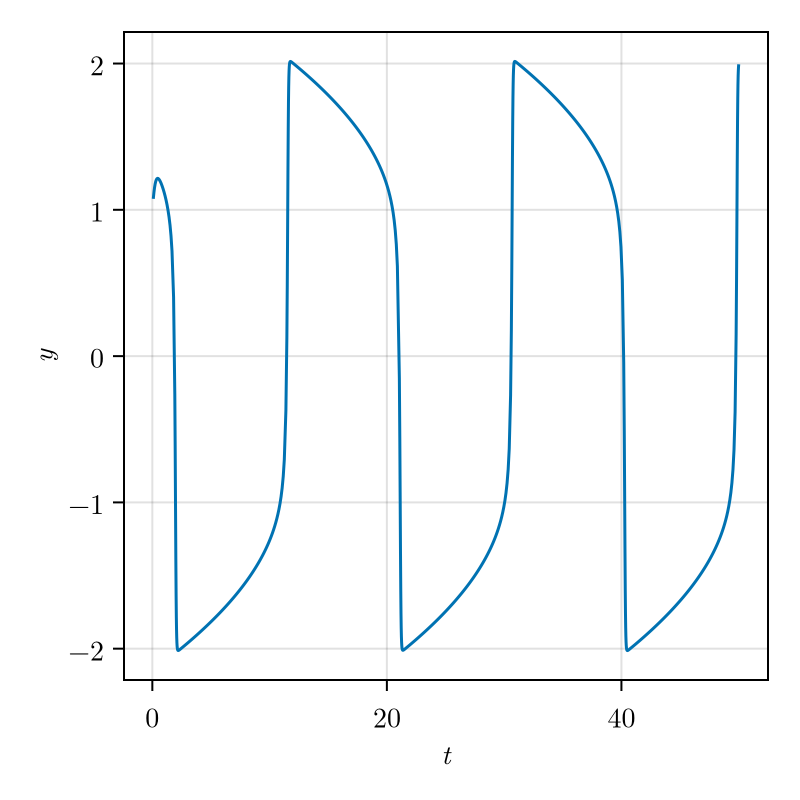

CairoMakie.Screen{IMAGE}


In [27]:
fig = Figure(size = (400,400))
ax = Axis(fig[1,1], xlabel = L"t", ylabel = L"y")

y1 = [first(ui) for ui in sol.u]
t = sol.t
lines!(ax, t[2:end], y1[2:end])
display(fig)

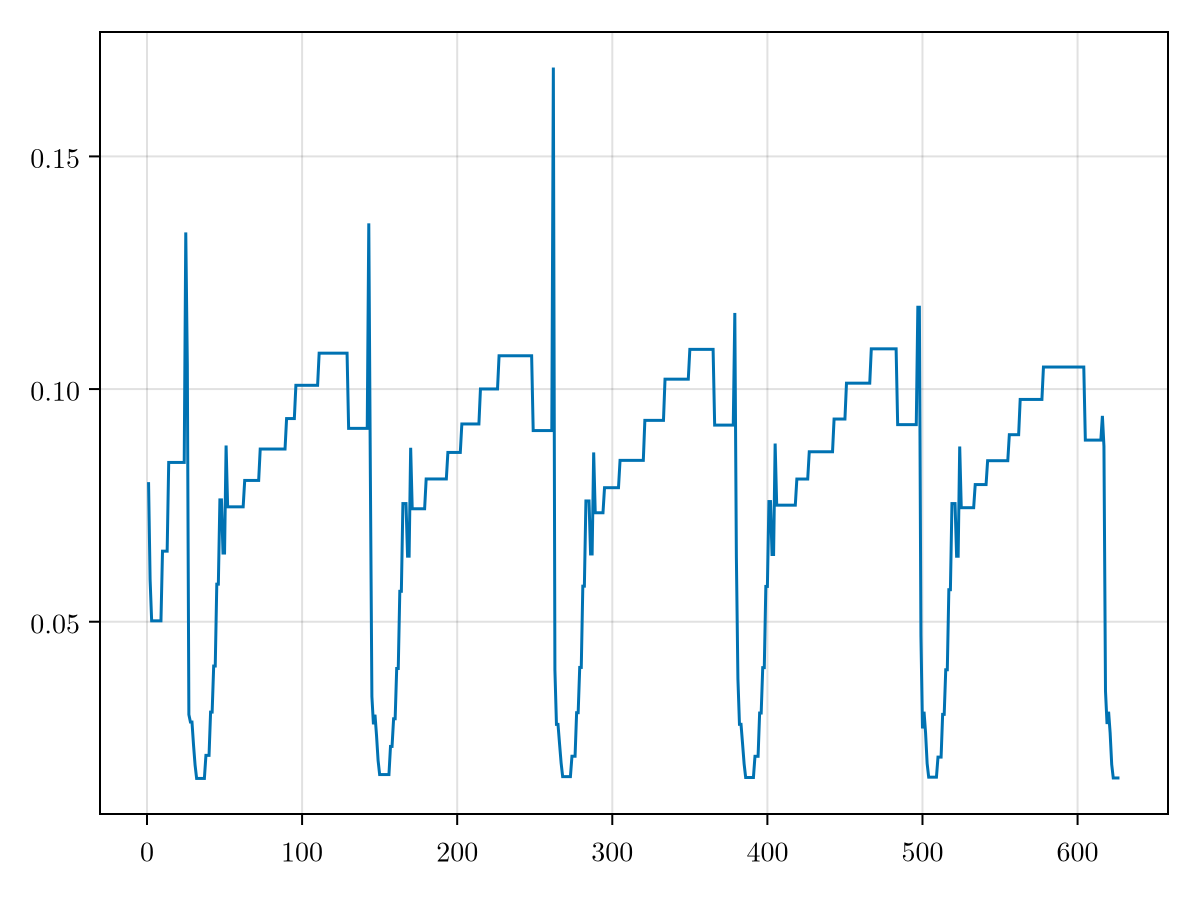

In [28]:
lines(sol.t[2:end] - sol.t[1:end-1])

In [ ]:
#1) update algorithm cache (i.e. get everything needed to compute the candidate u)
prepare_step!(cache, state, prob)   

#2) Compute candidate u & update adaptive cache (which stores dt, u_current, u_candidate)
compute_candidate!(cache, state, prob)

#3) Compute error estimate
compute_error_estimate!(cache, state, prob)

#4) Decide whether to accept or reject the step, and update dt accordingly 
step_result, μ = process_step!(ETDRK43(), state, adaptive_options)

In [ ]:
state.dt = 0.01
adaptive_options = AdaptiveOptions(abstol = 1e-6, reltol = 1e-3)

prepare_step!(cache, state, prob)   
compute_candidate!(cache, state, prob)
compute_error_estimate!(cache, state, prob)
step_result, μ = process_step!(ETDRK43(), state, adaptive_options)